In [208]:
# Numerical arrays
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold

# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Model evaluation
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                            roc_curve, ConfusionMatrixDisplay, precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score)

# Model optimization
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier

import shap
from google.colab import drive
drive.mount('/content/drive')

# Store the model
import joblib
#

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Data Loading and Preprocessing**

In [209]:
# Reading the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

In [210]:
df = df.drop(["Unnamed: 0", "gender"], axis=1)

# **2. Data Splitting**

In [211]:
# Seperate independent and dependent variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [212]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [213]:
# Get categorical (nominal + ordinal), numerical features for later preprocessing
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns.drop('Contract')  # Exclude the ordinal column
ordinal_feature = ['Contract']  # Contracts get better from Month-to-month to One year to Two year

# **3. Create Preprocessing Pipeline**

In [214]:
# Categorical (excluding ordinal)
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # convert each column into seperate binary columns
])

# Ordinal feature
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[
        ['Month-to-month', 'One year', 'Two year']  # Month-to-month < One year < Two year
    ]))
])

# Create the preprocessor
preprocessor = ColumnTransformer(   # combine all preprocessing for mixed data types
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_feature)
    ],
    remainder='passthrough' # keep the numerical features as they are
)

In [261]:
def clean_feature_names(feature_names):
    """
    Clean feature names by removing transformer prefixes
    Example: 'cat__InternetService_DSL' -> 'InternetService_DSL'
    """
    cleaned_names = []

    for name in feature_names:
        # Remove transformer prefixes
        if name.startswith('cat__'):
            name = name[5:]  # Remove 'cat__'
        elif name.startswith('ord__'):
            name = name[5:]  # Remove 'ord__'
        elif name.startswith('remainder__'):
            name = name[11:]  # Remove 'remainder__'

        # Replace underscores with spaces for better readability
        name = name.replace('_', ' ')

        # Capitalize each word
        name = ' '.join(word.capitalize() for word in name.split())

        cleaned_names.append(name)

    return cleaned_names

In [215]:
# Fit the preprocessor
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [216]:
# Get the feature names
feature_names = preprocessor.get_feature_names_out()

In [217]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [218]:
def predict_with_threshold(model, threshold=0.5):
  """
  Used to make predictions with a threshold value
  """
  y_prob = model.predict_proba(X_test)[:, 1]
  y_pred = (y_prob > threshold).astype(int)

  return (y_pred, y_prob)

In [219]:
# Create base model
base_tree = DecisionTreeClassifier(random_state=42,
                                   class_weight=class_weight_dict)

base_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: np.float64(0.6805991785455424),
                                     1: np.float64(1.8842809364548494)},
                       random_state=42)

In [220]:
# Make predictions
y_pred_base = base_tree.predict(X_test)
y_pred_proba_base = base_tree.predict_proba(X_test)[:, 1]

In [221]:
# Store base metrics
base_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-Score': f1_score(y_test, y_pred_base),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_base)
}

In [222]:
def check_overfitting_underfitting(train_accuracy, test_accuracy):
  """
  Used to check if a model is overfitting or underfitting by
  plotting a graph
  """
  metrics = {
      'Dataset': ['Train', 'Test'],
      'Accuracy':
      [
          train_accuracy,
          test_accuracy
      ]
  }

  df_metrics = pd.DataFrame(metrics)

  # Plot
  fig = px.bar(df_metrics, x='Dataset', y='Accuracy', text='Accuracy',
              title='Train and Test Accuracies',
              color='Dataset')
  fig.show()

In [223]:
def evaluate(model_name, y_prob, y_pred, y_true):
  """
  Used to evaluate a model and plot a confusion matrix
  """
  print(f"Model: {model_name}")
  print(classification_report(y_true, y_pred, target_names=['No churn', 'Churn']))

  cm = confusion_matrix(y_true, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()

Model: Base Tree
              precision    recall  f1-score   support

    No churn       0.81      0.82      0.82      1035
       Churn       0.49      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.73      1409



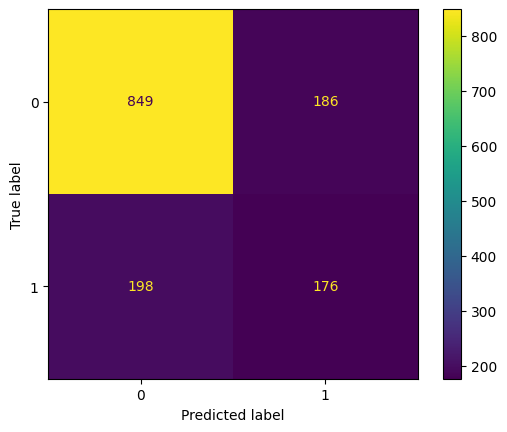

In [224]:
# evaluate base tree
evaluate("Base Tree", y_pred_proba_base, y_pred_base, y_test)

In [225]:
# Get the training and test accuracies and check for overfitting/underfitting
train_acc_base = base_tree.score(X_train, y_train)
test_acc_base = base_tree.score(X_test, y_test)
check_overfitting_underfitting(train_acc_base, test_acc_base)

In [226]:
def visualize_importances(model, feature_names, total_features=15):
  """
  Plots the feature importances for the decision tree in descending order
  """
  importances = model.feature_importances_

  # Create a dataframe
  feat_df = pd.DataFrame({
      'Feature': feature_names,
      'Importance': importances
  }).sort_values('Importance', ascending=False) # in descending order

  print(f"Top {total_features}:")
  top_feats = feat_df.head(total_features)  # Get the required amount of features

  top_feats_sorted = top_feats.sort_values(by='Importance', ascending=False)  # sort so the highest importance is at the front

  # Make a barplot
  fig = px.bar(
      top_feats_sorted,
      x='Feature',
      y='Importance',
      color='Importance',
      color_continuous_scale='viridis',
      title=f"Top {total_features} Feature Importances"
  )

  # Set the figure layout
  fig.update_layout(
      xaxis_title='Feature',
      yaxis_title='Importance',
      height=600
  )

  fig.show()

In [227]:
visualize_importances(base_tree, feature_names, 15)

Top 15:


# **Hyperparameter Tuning**

In [228]:
# Hyperparameters to tune
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10, 15],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.05, 0.1],  # Cost complexity pruning
    'max_leaf_nodes': [None, 50, 100, 200, 300]
}

In [229]:
# base model creation
base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight_dict)

In [230]:
# Perform random search
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50, # Number of parameter combinations to try
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [231]:
# Fit with the training data
random_search.fit(X_train, y_train)

Fitting 10 folds for each of 50 candidates, totalling 500 fits


RandomizedSearchCV(cv=10,
                   estimator=DecisionTreeClassifier(class_weight={0: np.float64(0.6805991785455424),
                                                                  1: np.float64(1.8842809364548494)},
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.005, 0.01,
                                                      0.05, 0.1],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10, 15, 20, 25,
                                                      30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'max_leaf_nodes': [None, 50, 100, 200,
                                                           300],
                                        'min_samples_leaf': [1, 2, 4, 8, 10,
                                                             15],
                                        'min_samples_split': [2, 5, 10, 20,
                                                              30]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [232]:
# Show the best auc score and the best parameters
print("Best ROC-AUC Score:", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

Best ROC-AUC Score: 0.8251838549824979
Best Parameters: {'min_samples_split': 30, 'min_samples_leaf': 8, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 5, 'criterion': 'gini', 'ccp_alpha': 0.0}


In [233]:
# train best model
best_tree = random_search.best_estimator_
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: np.float64(0.6805991785455424),
                                     1: np.float64(1.8842809364548494)},
                       max_depth=5, min_samples_leaf=8, min_samples_split=30,
                       random_state=42)

In [234]:
# Predictions for the best tree
y_pred_best = best_tree.predict(X_test)
y_prob_best = best_tree.predict_proba(X_test)[:, 1]

In [235]:
# Store the tuned tree metrics
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1-Score': f1_score(y_test, y_pred_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best)
}

In [236]:
# Show the classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [237]:
# Check for overfitting/underfitting
check_overfitting_underfitting(best_tree.score(X_train, y_train), best_tree.score(X_test, y_test))

In [238]:
# Describing the tree after pruning
print(f"Tree complexity after tuning")
print(f"Tree Depth: {best_tree.get_depth()}")
print(f"Tree Leaf Count: {best_tree.get_n_leaves()}")
print(f"Number of features used: {np.sum(best_tree.feature_importances_ > 0)}")

Tree complexity after tuning
Tree Depth: 5
Tree Leaf Count: 31
Number of features used: 14


# **Model Comparison**

In [239]:
# Create a dataframe to store the models and the metrics
comparisons_df = pd.DataFrame({
    'Metric': list(base_metrics.keys()),
    'Base Model': [base_metrics[metric] for metric in base_metrics.keys()],
    'Tuned Model': [tuned_metrics[metric] for metric in tuned_metrics.keys()]
})

In [240]:
# Calculating improvement
comparisons_df['Improvement'] = comparisons_df['Tuned Model'] - comparisons_df['Base Model']
comparisons_df['Improvement (%)'] = (comparisons_df['Improvement'] / comparisons_df['Base Model']) * 100

In [241]:
print("Performance Comparison:\n")
comparisons_df

Performance Comparison:



,Metric,Base Model,Tuned Model,Improvement,Improvement (%)
0,Accuracy,0.727466,0.755855,0.028389,3.902439
1,Precision,0.486188,0.527881,0.041693,8.575532
2,Recall,0.470588,0.759358,0.288770,61.363636
3,F1-Score,0.478261,0.622807,0.144546,30.223285
4,ROC-AUC,0.645894,0.832458,0.186564,28.884605


In [242]:
# Plot comparisons
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

fig = go.Figure()

# Base model bars
fig.add_trace(go.Bar(
    x=comparisons_df['Metric'],
    y=comparisons_df['Base Model'],
    name='Base Model',
    marker_color="#3498db",
    text=[f"{v:.3f}" for v in comparisons_df['Base Model']],
    textposition="outside"
))

# Tuned model bars
fig.add_trace(go.Bar(
    x=comparisons_df['Metric'],
    y=comparisons_df['Tuned Model'],
    marker_color="#2ecc71",
    text=[f"{v:.3f}" for v in comparisons_df['Tuned Model']],
    textposition="outside",
    name='Tuned Model'
))

fig.update_layout(
  title = "Model Performance Comparison (Base vs Tuned)",
  yaxis_title='Score',
  barmode='group',
  plot_bgcolor='white',
  font=dict(size=12),
  bargroupgap=0.15,
  bargap=0.20,
  xaxis=dict(showgrid=True, gridcolor='lightgray'),
  yaxis=dict(showgrid=True, gridcolor='lightgray'),
)

fig.show()

In [243]:
# Plot ROC and PR Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_base)
roc_auc_base = roc_auc_score(y_test, y_pred_proba_base)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_best)
roc_auc_tuned = roc_auc_score(y_test, y_prob_best)

precision_base, recall_base, _ = precision_recall_curve(y_test, y_pred_base)
precision_tuned, recall_tuned, _ = precision_recall_curve(y_test, y_prob_best)

In [244]:
# ROC Curve for base tree vs tuned tree
fig_roc = go.Figure()

# Base tree
fig_roc.add_trace(go.Scatter(
    x=fpr_base,
    y=tpr_base,
    mode='lines',
    name=f"Base Model AUC = {roc_auc_base:.3f}",
    line=dict(width=2, color="#3498db")
))

# Tuned tree
fig_roc.add_trace(go.Scatter(
    x=fpr_tuned,
    y=tpr_tuned,
    mode='lines',
    name=f"Tuned Model AUC = {roc_auc_tuned:.3f}",
    line=dict(width=2, color="#2ecc71")
))

# Random classifier
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Random Guess',
    line=dict(width=1, color='grey', dash='dash')
))

fig_roc.update_layout(
    title='ROC Curve Comparison (Base vs Tuned)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    font=dict(size=12)
)


In [245]:
# Precision recall curve for the base tree and tuned tree
fig_pr = go.Figure()

# Base tree
fig_pr.add_trace(go.Scatter(
    x=recall_base,
    y=precision_base,
    mode='lines',
    name='Base Model',
    line=dict(width=2, color='#3498db')
))

# Tuned tree
fig_pr.add_trace(go.Scatter(
    x=recall_tuned,
    y=precision_tuned,
    mode='lines',
    name='Tuned Model',
    line=dict(width=2, color='#2ecc71')
))

# Set the figure layout
fig_pr.update_layout(
    title='Precision-Recall Curve Comparison (Base vs Tuned)',
    xaxis_title='Recall',
    yaxis_title='Precision',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'), # grid lines
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    font=dict(size=12)
)

fig_pr.show()

In [246]:
# Cross validation
cv_scores_base = cross_val_score(base_tree, X_train, y_train,
                                 cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
                                 scoring='roc_auc',
                                 n_jobs=-1)

cv_scores_tuned = cross_val_score(best_tree, X_train, y_train,
                                  cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
                                  scoring='roc_auc',
                                  n_jobs=-1)

print("Cross Val ROC AUC for Base Model:", cv_scores_base.mean())
print("Cross Val ROC AUC for Tuned Model:", cv_scores_tuned.mean())

Cross Val ROC AUC for Base Model: 0.6550874724256988
Cross Val ROC AUC for Tuned Model: 0.8279735210951596


In [247]:
# Plot a boxplot to visualize and compare the cross val scores
fig = px.box(pd.DataFrame({
    'Base Model': cv_scores_base,
    'Tuned Model': cv_scores_tuned}))

fig.update_layout(
    title='Boxplot of Cross-Validation Scores',
    xaxis_title='Model',
    yaxis_title='ROC-AUC Score',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

Model: Base Tree
              precision    recall  f1-score   support

    No churn       0.81      0.82      0.82      1035
       Churn       0.49      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.73      1409



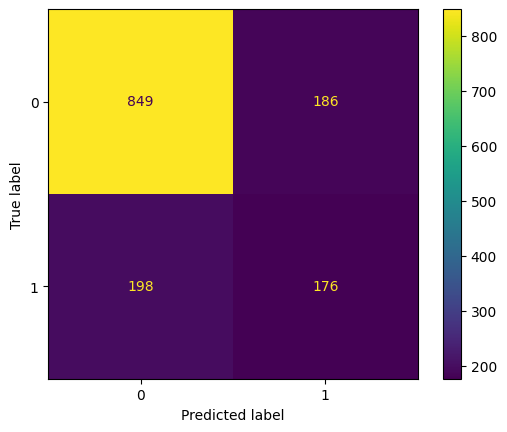

In [248]:
# Evaluate the base tree
evaluate("Base Tree", y_pred_proba_base, y_pred_base, y_test)

Model: Best Model
              precision    recall  f1-score   support

    No churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



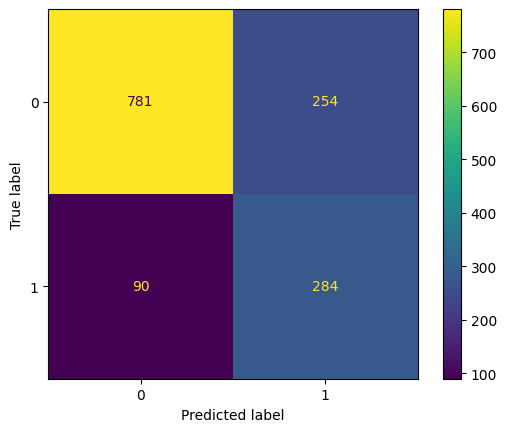

In [249]:
# Evaluate the best tree
evaluate("Best Tree", y_prob_best, y_pred_best, y_test)

# **Feature Importance Analysis**

In [250]:
print("Base tree feature importance:\n")
visualize_importances(base_tree, feature_names, 15)

Base tree feature importance:

Top 15:


In [251]:
print("Best tree importances:\n")
visualize_importances(best_tree, feature_names, 15)

Best tree importances:

Top 15:


In [252]:
y_best_threshold_pred_labels, y_best_threshold_proba = predict_with_threshold(best_tree, 0.4)

print(classification_report(y_test, y_best_threshold_pred_labels))

              precision    recall  f1-score   support

           0       0.92      0.66      0.77      1035
           1       0.47      0.84      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.72      1409



In [253]:
y_best_threshold_pred_labels, y_best_threshold_proba = predict_with_threshold(best_tree, 0.45)

print(classification_report(y_test, y_best_threshold_pred_labels))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



# **5. Pruning**

In [254]:
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs Effective alpha for training set')

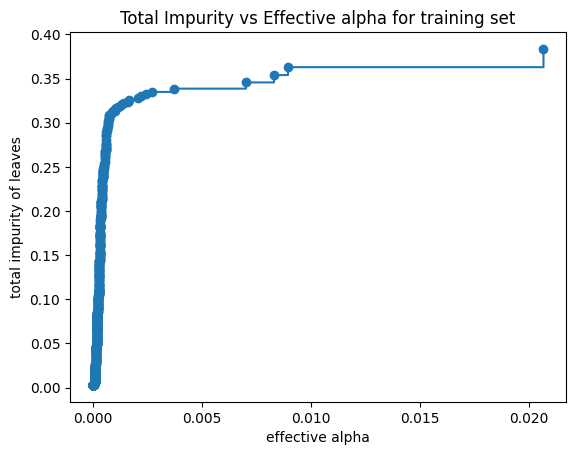

In [255]:
# Visualize alpha w.r.t leaves
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle='steps-post') # as alpha increases then low predictive branches get cut
ax.set_xlabel('effective alpha')
ax.set_ylabel('total impurity of leaves')
ax.set_title('Total Impurity vs Effective alpha for training set')

In [256]:
clfs = []

# ccp_alphas = [alpha for alpha in ccp_alphas if alpha >= 0]

for ccp_alpha in ccp_alphas:
  clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
  clf.fit(X_train, y_train)
  clfs.append(clf)
  print(f"Number of nodes in the last tree is {clfs[-1].tree_.node_count} with ccp alpha = {ccp_alphas[-1]}")

Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.11645317405336253
Number of nodes in the last tree is 2223 with ccp alpha = 0.1164

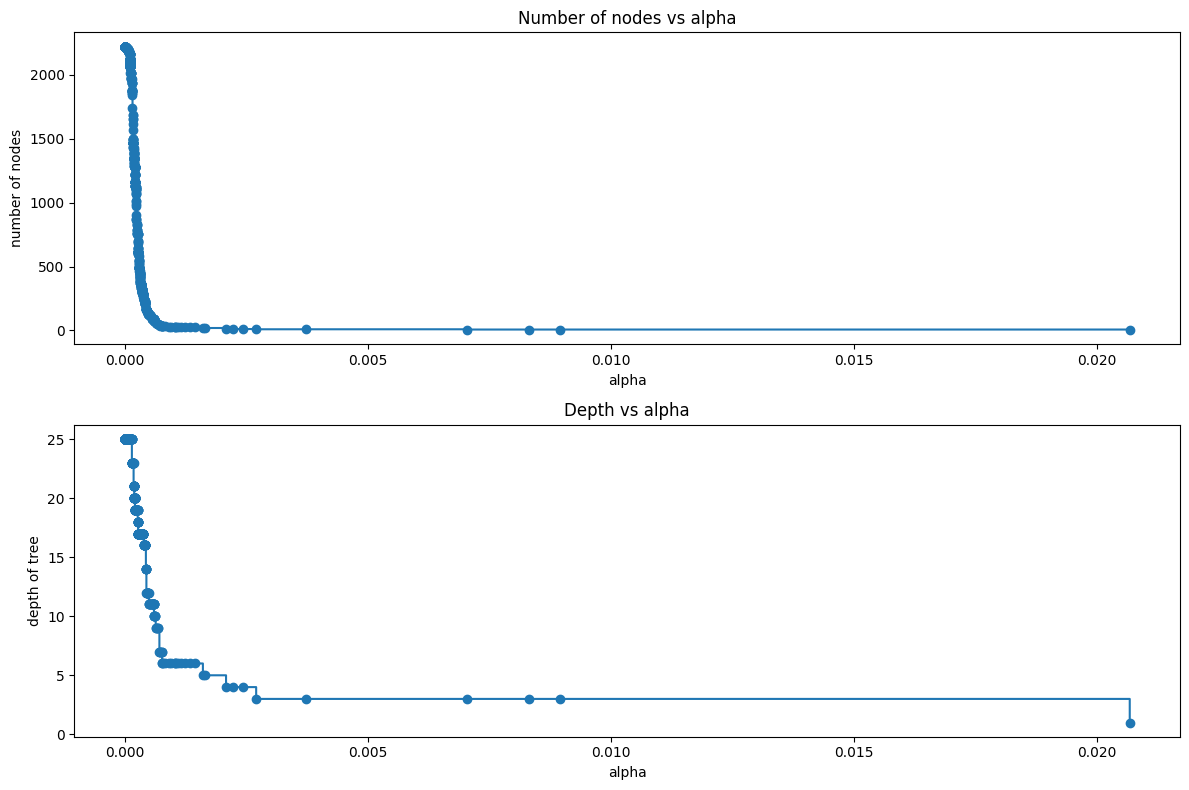

In [257]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(12,8))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

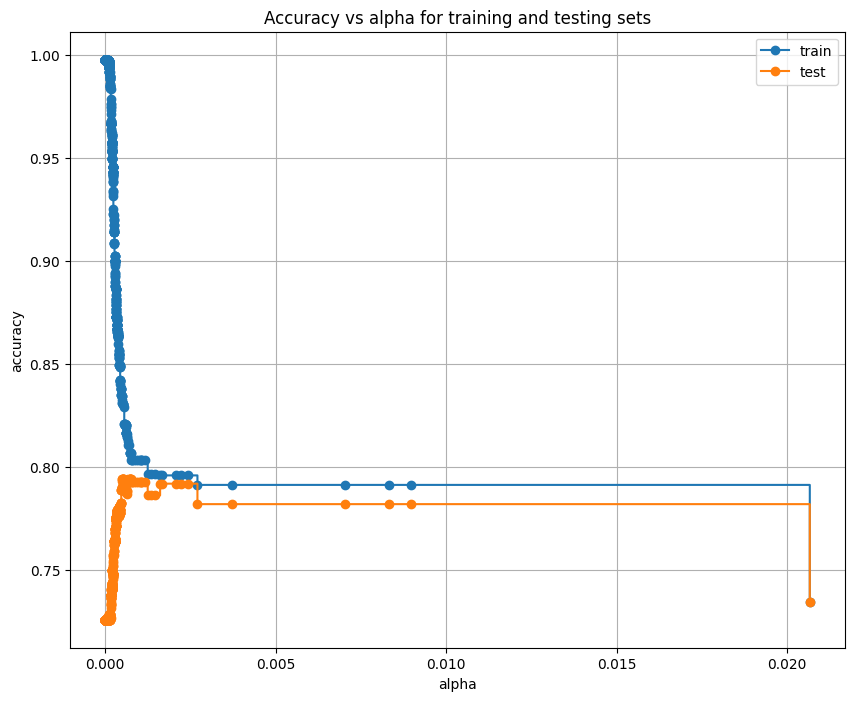

In [258]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.grid()
plt.show()

In [259]:
# Use the ccp alpha from the graph
clf = DecisionTreeClassifier(ccp_alpha=0.0007)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [260]:
clfs = []

for ccp_alpha in ccp_alphas:
  clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
  clf.fit(X_train_balanced, y_train_balanced)
  clfs.append(clf)
  print(f"Number of nodes in the last tree is {clfs[-1].tree_.node_count} with ccp alpha = {ccp_alphas[-1]}")

NameError: name 'X_train_balanced' is not defined

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(12,8))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.grid()
plt.show()

In [ ]:
clf = DecisionTreeClassifier(ccp_alpha=0.010)
clf.fit(X_train_balanced, y_train_balanced)
pred = clf.predict(X_test)
print(classification_report(y_test, pred))

In [ ]:
grid.fit(X_train_balanced, y_train_balanced)

In [ ]:
print(classification_report(y_test, grid.best_estimator_.predict(X_test)))

In [ ]:
y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

In [ ]:
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10,15,20],
    'min_samples_leaf': [1, 2, 4, 8,12]
}

# **9. Plot The Tree**

In [ ]:
best_model = grid.best_estimator_

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(best_model, feature_names=X_train_selected.columns, class_names=['No','Yes'], filled=True)
plt.show()


In [ ]:
# Get feature importance
importances = pd.Series(best_model.feature_importances_, index=pd.DataFrame(X_train).columns)
importances = importances.sort_values(ascending=False)
print(importances)